## 1. Import libraries and data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from pathlib import Path
import sys

PROJECT_DIR = Path.cwd().resolve().parents[0]
sys.path.append(str(PROJECT_DIR))

from src.clustering import k_distance_elbow_plot

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from kneed import KneeLocator
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [2]:
PROJECT_DIR = Path.cwd().resolve().parents[0]

data_path = PROJECT_DIR / "data" / "processed" / "model_table.csv"

df = pd.read_csv(data_path)

FEATURE_COLS = ["Age", "Annual_income_thousands", "Spending_score"]
CATEGORY_COL = ["Gender"]
X = df[FEATURE_COLS]
X.head()

,Age,Annual_income_thousands,Spending_score
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


## 2. Standardize data

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 3. DBSCAN

## 3.1 Elbow plot for choosing `eps` for DBSCAN

{6: 0.7862004297656514,
 7: 0.775244945504569,
 8: 0.9637426556133273,
 9: 1.0062975976462716,
 10: 0.963611917707681,
 11: 1.2959726403179148,
 12: 0.9705751411512561}

<Figure size 640x480 with 0 Axes>

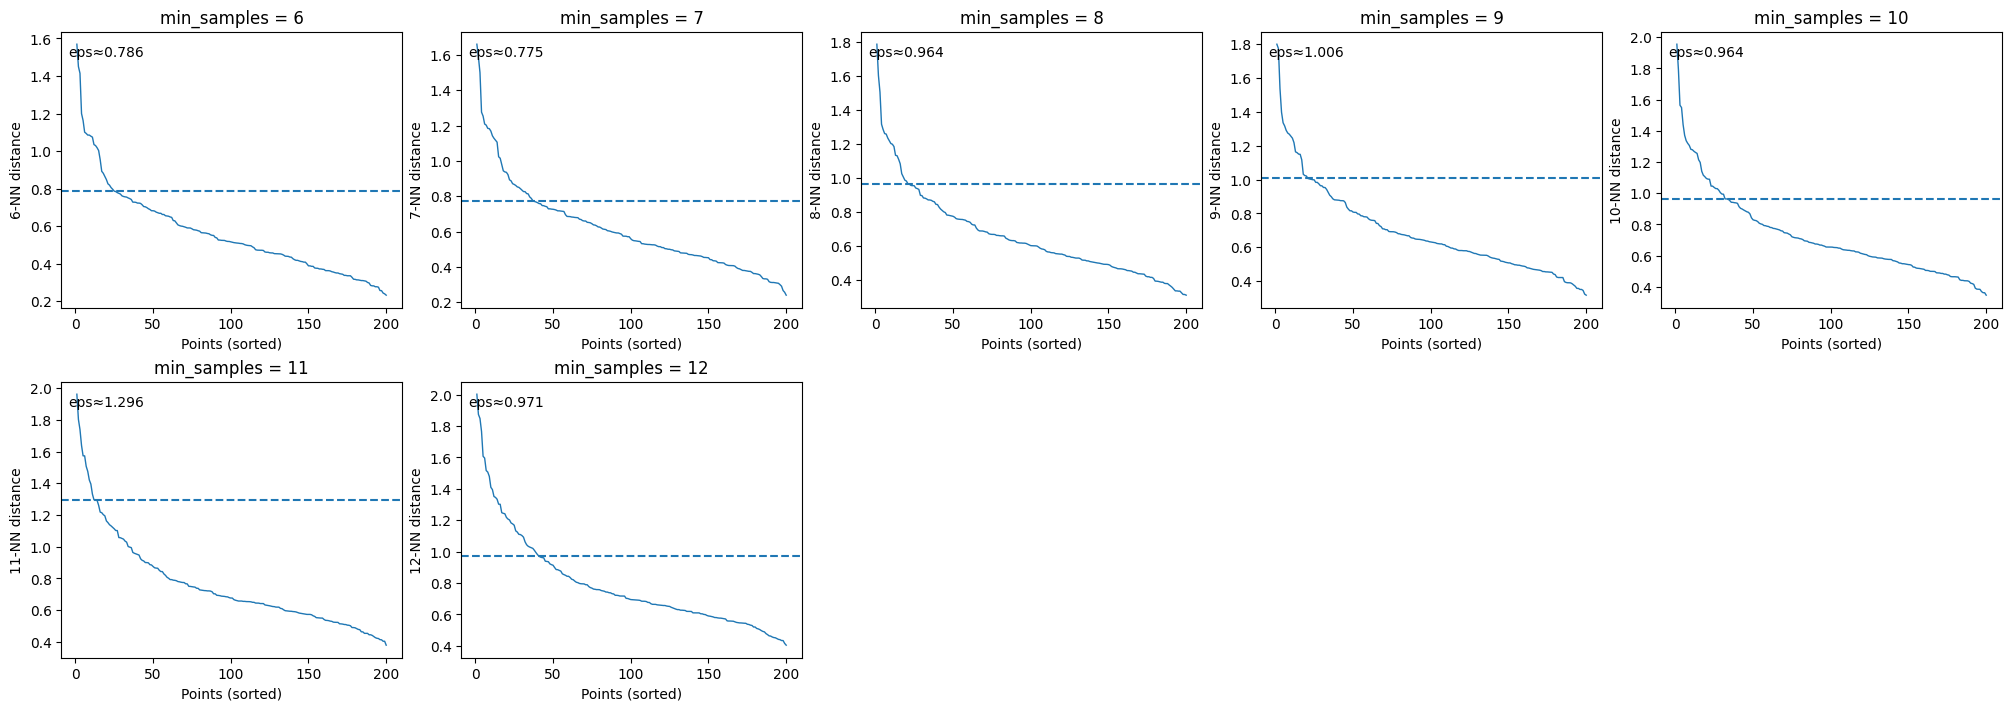

In [4]:
SAVE_FIG = PROJECT_DIR / "reports" / "figures" / "DBSCAN_elbow.png"

plt.savefig(SAVE_FIG, dpi = 300, bbox_inches = "tight")
min_saples_vals = range(6,13)

fig, eps_guess_list, eps_by_ms = k_distance_elbow_plot(
    df = X,
    min_samples_values = min_saples_vals,
    ncols = 5,
    S = 1.4
)

display(eps_by_ms)
plt.savefig(SAVE_FIG, dpi = 300, bbox_inches = "tight")
plt.show()

## 3.2 Run different configuration models

In [5]:
eps_values = eps_guess_list
min_samples_values = list(min_saples_vals)

rows = []

# for each eps_guess, take values at +- 0.3 and fit the model
for eps_guess, ms in zip(eps_values, min_samples_values):
    for eps in [float(eps_guess) - 0.3, float(eps_guess), float(eps_guess) + 0.3]:
        if eps <= 0:
            continue

        model = DBSCAN(eps=eps, min_samples=int(ms))
        labels = model.fit_predict(X_scaled)

        # exclude noise for scoring
        mask = labels != -1
        labels_nn = labels[mask]
        X_nn = X_scaled[mask]

        # count clusters excluding noise
        n_clusters = len(set(labels_nn)) if len(labels_nn) > 0 else 0

        sil = dbi = ch = np.nan
        if n_clusters >= 2:
            sil = silhouette_score(X_nn, labels_nn)
            dbi = davies_bouldin_score(X_nn, labels_nn)
            ch = calinski_harabasz_score(X_nn, labels_nn)

        rows.append(
            {
                "eps_guess": float(eps_guess),
                "eps": float(eps),
                "min_samples": int(ms),
                "n_clusters": int(n_clusters),
                "noise_frac": float((labels == -1).mean()),
                "silhouette": sil,
                "davies_bouldin": dbi,
                "calinski_harabasz": ch,
            }
        )

dbscan_metrics = pd.DataFrame(rows).sort_values(
    by=["silhouette", "calinski_harabasz"], ascending=[False, False]
)

dbscan_metrics

,eps_guess,eps,min_samples,n_clusters,noise_frac,silhouette,davies_bouldin,calinski_harabasz
0,0.786200,0.486200,6,5,0.350,0.536464,0.593099,146.131018
3,0.775245,0.475245,7,6,0.430,0.496079,0.634301,163.589785
18,0.970575,0.670575,12,4,0.240,0.351111,0.903084,60.588589
6,0.963743,0.663743,8,3,0.210,0.271808,1.031517,45.494996
12,0.963612,0.663612,10,3,0.225,0.270372,1.029765,42.579671
1,0.786200,0.786200,6,1,0.030,NaN,NaN,NaN
2,0.786200,1.086200,6,1,0.000,NaN,NaN,NaN
4,0.775245,0.775245,7,1,0.050,NaN,NaN,NaN
5,0.775245,1.075245,7,1,0.010,NaN,NaN,NaN
7,0.963743,0.963743,8,1,0.020,NaN,NaN,NaN


In [6]:
# manually defined values for eps and min_samples
"""
eps_values = np.linspace(0.2, 2.0, 10)
min_samples_values = range(4, 12)

rows = []

for eps in eps_values:
    for ms in min_samples_values:
        model = DBSCAN(eps=float(eps), min_samples=int(ms))
        labels = model.fit_predict(X_scaled)

        # exclude noise for scoring
        mask = labels != -1
        labels_nn = labels[mask]
        X_nn = X_scaled[mask]

        # count clusters excluding noise
        n_clusters = len(set(labels_nn)) if len(labels_nn) > 0 else 0

        sil = dbi = ch = np.nan
        if n_clusters >= 2:
            sil = silhouette_score(X_nn, labels_nn)
            dbi = davies_bouldin_score(X_nn, labels_nn)
            ch = calinski_harabasz_score(X_nn, labels_nn)

        rows.append(
            {
                "eps": float(eps),
                "min_samples": int(ms),
                "n_clusters": int(n_clusters),
                "noise_frac": float((labels == -1).mean()),
                "silhouette": sil,
                "davies_bouldin": dbi,
                "calinski_harabasz": ch,
            }
        )

dbscan_metrics = pd.DataFrame(rows).sort_values(
    by=["silhouette", "calinski_harabasz"], ascending=[False, False]
)
dbscan_metrics.head(15)
"""

'\neps_values = np.linspace(0.2, 2.0, 10)\nmin_samples_values = range(4, 12)\n\nrows = []\n\nfor eps in eps_values:\n    for ms in min_samples_values:\n        model = DBSCAN(eps=float(eps), min_samples=int(ms))\n        labels = model.fit_predict(X_scaled)\n\n        # exclude noise for scoring\n        mask = labels != -1\n        labels_nn = labels[mask]\n        X_nn = X_scaled[mask]\n\n        # count clusters excluding noise\n        n_clusters = len(set(labels_nn)) if len(labels_nn) > 0 else 0\n\n        sil = dbi = ch = np.nan\n        if n_clusters >= 2:\n            sil = silhouette_score(X_nn, labels_nn)\n            dbi = davies_bouldin_score(X_nn, labels_nn)\n            ch = calinski_harabasz_score(X_nn, labels_nn)\n\n        rows.append(\n            {\n                "eps": float(eps),\n                "min_samples": int(ms),\n                "n_clusters": int(n_clusters),\n                "noise_frac": float((labels == -1).mean()),\n                "silhouette": sil,\

## 3.3 Filter and pick best configuration

In [7]:
def best_dbscan_config(
    dbscan_grid: pd.DataFrame,
    max_noise: float = 0.3,
    min_clusters: int = 4,
) -> pd.Series:
    df = dbscan_metrics.copy()

    df = df[df["n_clusters"].fillna(0).astype(int) >= min_clusters]
    df = df[df["noise_frac"].fillna(1.0) <= max_noise]
    df = df.dropna(subset=["silhouette", "davies_bouldin", "calinski_harabasz"])

    if df.empty:
        raise ValueError(
            "No DBSCAN configs left after filtering. "
            "Change max_noise or widen eps/min_samples grid."
        )

    # rank
    df = df.sort_values(
        by=["silhouette", "calinski_harabasz", "davies_bouldin", "noise_frac"],
        ascending=[False, False, True, True],
    )

    return df.iloc[0]

best_cfg = best_dbscan_config(dbscan_metrics, max_noise=0.30)
best_cfg

eps_guess             0.970575
eps                   0.670575
min_samples          12.000000
n_clusters            4.000000
noise_frac            0.240000
silhouette            0.351111
davies_bouldin        0.903084
calinski_harabasz    60.588589
Name: 18, dtype: float64

## 3.4 Rerun model with best configuration

In [8]:
eps = best_cfg.eps
min_samples = int(best_cfg.min_samples)


db = DBSCAN(eps=eps, min_samples=min_samples)
labels = db.fit_predict(X_scaled)

is_noise = labels == -1
noise_frac = is_noise.mean()
cluster_labels = sorted(set(labels) - {-1})
n_clusters = len(cluster_labels)

print(f"Chosen DBSCAN config: eps={eps}, min_samples={min_samples}")
print(f"n_clusters={n_clusters}, noise_frac={noise_frac:.3f}")

# Evaluate metrics without noise
mask = ~is_noise
X_core = X_scaled[mask]
y_core = labels[mask]

n_clusters_core = len(set(y_core))
if n_clusters_core >= 2:
    sil = silhouette_score(X_core, y_core)
    dbi = davies_bouldin_score(X_core, y_core)
    ch  = calinski_harabasz_score(X_core, y_core)
else:
    sil, dbi, ch = np.nan, np.nan, np.nan

print(f"silhouette={sil:.4f}, davies_bouldin={dbi:.4f}, calinski_harabasz={ch:.2f}")

Chosen DBSCAN config: eps=0.6705751411512562, min_samples=12
n_clusters=4, noise_frac=0.240
silhouette=0.3511, davies_bouldin=0.9031, calinski_harabasz=60.59


## 3.5 Plot clusters

In [9]:
import plotly.graph_objects as go
import plotly.express as px

df_original = df[FEATURE_COLS].to_numpy()

# plot dataframe
plot_df = pd.DataFrame(df_original, columns=FEATURE_COLS).assign(
    cluster=labels.astype(str)
)

# points
fig = px.scatter_3d(
    plot_df,
    x=FEATURE_COLS[0],
    y=FEATURE_COLS[1],
    z=FEATURE_COLS[2],
    color="cluster",
    opacity=0.85,
)

fig.update_layout(
    title="DBSCAN clusters (3D)",
    scene=dict(
        xaxis_title=FEATURE_COLS[0],
        yaxis_title=FEATURE_COLS[1],
        zaxis_title=FEATURE_COLS[2],
    ),
    legend=dict(
        title="Cluster",
        itemsizing="constant",
        x=1.15,
        y=1,
        xanchor="left",
        yanchor="top"
    ),
    margin=dict(r=180)
)

fig.show()
fig.write_html(f"{PROJECT_DIR}/reports/figures/DBSCAN_clusters_3d.html", include_plotlyjs="cdn")

## 3.6 Cluster summary

In [16]:
labels = db.fit_predict(X_scaled)

dbscan_model = X.copy()
dbscan_model["cluster"] = labels

summary = (
    dbscan_model
    .groupby("cluster")[FEATURE_COLS]
    .agg(["count", "mean", "median", "std"])
)
summary

Age                              Annual_income_thousands             \
        count       mean median        std                   count       mean   
cluster                                                                         
-1         48  41.083333   37.5  12.700868                      48  62.666667   
 0         19  23.736842   23.0   3.739312                      19  26.105263   
 1         87  43.091954   47.0  16.277844                      87  55.413793   
 2         34  32.588235   32.0   3.838542                      34  81.647059   
 3         12  40.833333   41.5   4.260460                      12  84.250000   

                          Spending_score                               
        median        std          count       mean median        std  
cluster                                                                
-1        71.0  40.390821             48  28.125000   16.5  26.956723  
 0        25.0   7.964468             19  78.315789   77.0   8.253300  
 1        54.0   9.965699             87  48.390805   49.0   7.604094  
 2        78.0   9.698117             34  82.558824   85.5   9.532055  
 3        82.0   8.986100             12  15.416667   16.5   6.999459

### Clusters found:
0 - Young adults, low earners and high spenders (Age ~23, Income ~26k, Score ~78)  
1 - Mid-career adults, middle earners and middle spenders (Age ~43, Income ~55k, Score ~48)  
2 - Young professionals, high earners and high spenders (Age ~32, Income ~81k, Score ~82)  
3 - Mid-career adults, high earners and low spenders  (Age ~40, Income ~84k, Score ~15)  

#### Based on the parameters used (eps = 0.67 and min_sample = 12), DBSCAN has found a total of 5 clusters. Comapred to KMeans, DBSCAN has categorized many points as outliers, therefore not including them in any cluster. Since DBSCAN and KMeans are 2 different techniques, each with its advantage and disadvantage, based on the context in which they are used, it is expected that the results will be different. However, some of the clusters seem to coincide / overlap in both models.